In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

import noctiluca as nl
import bild
#import bayesmsd

from matplotlib import pyplot as plt
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['svg.fonttype'] = 'none'
%config InlineBackend.figure_format='retina'

from pathlib import Path

## load the tracks
all_tracks = pd.read_csv('../all_tracks.csv')

## write a function to grab the data for a given condition and ∆t (in the proper format for BILD)
def generate_data_list(condition, delta_t):
    filenames = all_tracks.loc[(all_tracks['condition']==condition) & (all_tracks['delta_t']==delta_t), 'path']

    data_list = []

    for filename in filenames:
        table_full = pd.read_csv(filename)
        table_xyz = np.array([table_full['pro_x (nm)']-table_full['enh_x (nm)'],
                            table_full['pro_y (nm)']-table_full['enh_y (nm)'],
                            table_full['pro_z (nm)']-table_full['enh_z (nm)']]).T / 1000  # convert to µm
        data_list.append(table_xyz)

    return data_list

/home/jjusuf/miniconda3/envs/bild/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jjusuf/miniconda3/envs/bild/lib/python3.9/site-packages/bild/cython_imports.py:6: UserWarning: Did not find compiled code for MSRouse_logL, falling back to python
  warn("Did not find compiled code for MSRouse_logL, falling back to python")


In [ ]:
data_30s = nl.TaggedSet()
traj_arrays = generate_data_list('S+V-A6B8_GSK', 30)
for arr in traj_arrays:
    traj = nl.Trajectory(arr)
    traj.meta['Δt'] = 30
    data_30s.add(traj)

In [130]:
short_names = ['G2','G2_dRAD21','S+V']
long_names = {}
long_names['G2'] = 'G7B8G2_GSK'
long_names['G2_dRAD21'] = 'G7B8G2_GSK_RAD21depletion'
long_names['S+V'] = 'S+V-A6B8_GSK'

data = {}
for name in short_names:
    data[name] = {}
    for dt_str in ['5s','30s']:
        dt = int(dt_str[:-1])
        data[name][dt_str] = nl.TaggedSet()
        traj_arrays = generate_data_list(long_names[name], dt)
        for arr in traj_arrays:
            traj = nl.Trajectory(arr)
            traj.meta['Δt'] = dt
            data[name][dt_str].add(traj)

params = {}
for name in short_names:
    params[name] = pd.read_csv(f'/mnt/md0/jjusuf/bild/synEP_bild/calibration/params_joint_fit_{long_names[name]}.csv', index_col=0).to_dict()['0']
    
    print(f'Fitted parameters for {long_names[name]}')
    print(f'σ_spot (∆t=5s) : {np.sqrt(np.exp(params[name]["5s log(σ²) (dim 0)"])/2)*1000:.1f} {np.sqrt(np.exp(params[name]["5s log(σ²) (dim 1)"])/2)*1000:.1f} {np.sqrt(np.exp(params[name]["5s log(σ²) (dim 2)"])/2)*1000:.1f} nm')
    print(f'σ_spot (∆t=30s): {np.sqrt(np.exp(params[name]["30s log(σ²) (dim 0)"])/2)*1000:.1f} {np.sqrt(np.exp(params[name]["30s log(σ²) (dim 1)"])/2)*1000:.1f} {np.sqrt(np.exp(params[name]["30s log(σ²) (dim 2)"])/2)*1000:.1f} nm')
    print(f'Γ      : {np.exp(params[name]["log(Γ)"]):.3} µm^2 s^-0.5')
    print(f'J      : {np.exp(params[name]["log(J)"]):.3} µm^2')
    print()

Fitted parameters for G7B8G2_GSK
σ_spot (∆t=5s) : 44.4 40.5 44.9 nm
σ_spot (∆t=30s): 44.8 43.7 44.4 nm
Γ      : 0.000353 µm^2 s^-0.5
J      : 0.0102 µm^2

Fitted parameters for G7B8G2_GSK_RAD21depletion
σ_spot (∆t=5s) : 89.1 75.2 74.8 nm
σ_spot (∆t=30s): 83.6 79.5 58.3 nm
Γ      : 0.00285 µm^2 s^-0.5
J      : 0.0922 µm^2

Fitted parameters for S+V-A6B8_GSK
σ_spot (∆t=5s) : 56.4 53.5 53.0 nm
σ_spot (∆t=30s): 61.1 61.3 60.3 nm
Γ      : 0.000866 µm^2 s^-0.5
J      : 0.0237 µm^2



In [70]:
sigma2s = {}
for name in short_names:
    sigma2s[name] = {}
    for dt_str in ['5s','30s']:
        sigma2s[name][dt_str] = np.sum(np.exp([params[name][f'{dt_str} log(σ²) (dim 0)'],
                                               params[name][f'{dt_str} log(σ²) (dim 1)'],
                                               params[name][f'{dt_str} log(σ²) (dim 2)']]))

In [71]:
msds = {}
R2_avgs = {}
for name in short_names:
    msds[name] = {}
    R2_avgs[name] = {}
    for dt_str in ['5s','30s']:
        msds[name][dt_str] = nl.analysis.MSD(data[name][dt_str]) - 2*sigma2s[name][dt_str]
        R2_avgs[name][dt_str] = np.nanmean(np.concatenate([traj.abs()[:][:, 0]**2 for traj in data[name][dt_str]])) - sigma2s[name][dt_str]
        

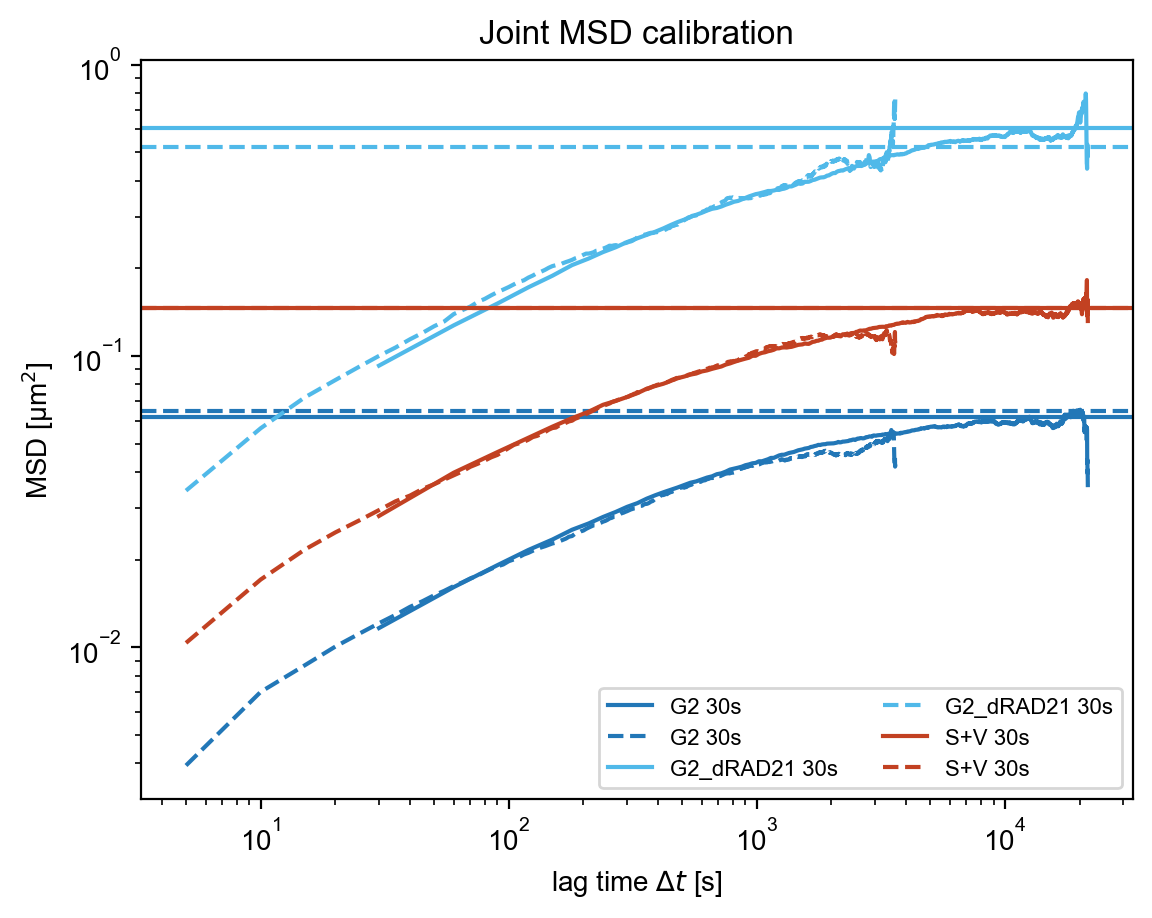

In [89]:
colors = {}
colors['G2'] = '#2277B7'
colors['G2_dRAD21'] = '#50B9E9'
colors['S+V'] = '#C24122'

fig, ax = plt.subplots()
for name in short_names:
    ax.plot(np.arange(1,len(msds[name]['30s']))*30, msds[name]['30s'][1:], color=colors[name], label=f'{name} 30s')
    ax.plot(np.arange(1,len(msds[name]['5s']))*5, msds[name]['5s'][1:], color=colors[name], linestyle='--', label=f'{name} 30s')
    ax.axhline(2*R2_avgs[name]['30s'], 0, 1, color=colors[name])
    ax.axhline(2*R2_avgs[name]['5s'], 0, 1, color=colors[name], linestyle='--')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('lag time $∆t$ [s]')
ax.set_ylabel('MSD [µm$^2$]')

handles, labels = plt.gca().get_legend_handles_labels()
ax.legend(handles, labels, ncol=2, loc='lower right', fontsize=8)

ax.set_title('Joint MSD calibration')

plt.show();


In [ ]:
# Unlooped state (ΔCTCF)
G = np.exp(params['S+V']['log(Γ)'])
J = np.exp(params['S+V']['log(J)'])

# Following eq. (5.22) in Simon's PhD thesis
L_min_30s = np.ceil(np.sqrt(4/np.pi)*J/G/np.sqrt(30)).astype(int)
L_min_5s = np.ceil(np.sqrt(4/np.pi)*J/G/np.sqrt(5)).astype(int)
L = 16
D = np.pi*L*G**2 / (4*J)
k = np.pi/4*(L*G/J)**2  # effectively k/gamma (lowercase gamma, that is)

# put in synEP parameters
tether_length_looped_kb = 1.8
dist_btwn_CTCF_sites_kb = 335

# Looped state (from ΔRad21, with genomic rescaling)
J_dRAD21 = np.exp(params['G2_dRAD21']['log(J)'])
J_looped = tether_length_looped_kb/dist_btwn_CTCF_sites_kb * J_dRAD21
L_looped = J_looped * k / D  # from Eq. 5.24 in Simon's thesis

## If L_looped > 1.6, apply decomposition by golden ratio, as described
## in Simon's PhD thesis, paragraph below eq. (5.25).
## Since here L_looped < 1 we spare the effort

print(f"{'Γ':>10s} = {G}")
print(f"{'J':>10s} = {J}")
print()
print(f"{'L_min_30s':>10s} = {L_min_30s}")
print(f"{'L_min_5s':>10s} = {L_min_5s}")
print(f"{'L':>10s} = {L}")
print()
print(f"{'D':>10s} = {D}")
print(f"{'k':>10s} = {k}")
print()
print(f"{'J_dRAD21':>10s} = {J_dRAD21}")
print(f"{'J_looped':>10s} = {J_looped}")
print(f"{'L_looped':>10s} = {L_looped}")



         Γ = 0.0008660947445330901
         J = 0.02370745621009323

 L_min_30s = 6
  L_min_5s = 14
         L = 16

         D = 0.0003976085489782292
         k = 0.2683432894391772

  J_dRAD21 = 0.09218346355095881
  J_looped = 0.0004953141325126146
  L_looped = 0.3342841193070653
